<a href="https://colab.research.google.com/github/WoojinCho-Ryan/Studying-Pytorch/blob/main/5_Softmax_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5-1. One-Hot Encoding

## 1. One-hot encoding?

One-hot encoding은 선택해야 하는 선택지의 개수만큼 dimension을 가지면서, 각 선택지의 index에 해당하는 원소는 1, 나머지 원소는 0의 값을 가지도록 하는 표현 방법.

Example:

강아지 = [1, 0, 0]

고양이 = [0, 1, 0]

냉장고 = [0, 0, 1]

이와 같이 one-hot encoding으로 표현된 vector를 **one-hot vector**라고 함.


## 2. One-hot vector의 randomness

$$\text{Loss function} = \frac{1}{n} \sum_{i}^{n} (y_{i} - \hat{y}_{i})^{2}$$

정수 encoding과 달리 one-ho encoding은 분류 문제 모든 클래스 간의 관계를 균등하게 분배.

# 5-2. Softmax Regression 이해하기

## 1. Multi-class Classification

아래의 문제는 4개의 feature로부터 setosa, versicolor, virginica라는 3개의 붓꽃 품종 중 어떤 품종인지를 예측하는 문제. 전형적인 Multi-class classification problem이다.

| SepalLengthCm($x_1$) | SepalWidthCm($x_2$) | PetalLengthCm($x_3$) | PetalWidthCm($x_4$) | Species($y$) |
| :---: | :---: | :---: | :---: | :---: |
| 5.1 | 3.5 | 1.4 | 0.2 | setosa |
| 4.9 | 3.0 | 1.4 | 0.2 | setosa |
| 5.8 | 2.6 | 4.0 | 1.2 | versicolor |
| 6.7 | 3.0 | 5.2 | 2.3 | virginica |
| 5.6 | 2.8 | 4.9 | 2.0 | virginica |

여기서 input은 $X$, weight은 $W$, bias는 $B$, output은 $\hat{Y}$로 표기. 각 variables는 vector 또는 matrix로 가정.
- $\hat{Y}$는 예측값이라는 의미를 가지고 있으므로 hypothesis에서 $H(X)$ 대신 사용되기도 함.

### 1) Logistic Resression

Hypothesis: $H(X) = sigmoid(WX+B)$

### 2) Softmax Regression

Hypothesis: $H(X) = softmax(WX + B)$

## 2. Softmax Function

### 1) Softmax function의 이해

k-dim vector에서 i번째 원소를 $z_i$, i번째 클래스가 정답일 확률을 $p_i$로 나타낸다고 했을 때, softmax function은 $p_i$을 다음과 같이 정의함.

$$p_i = \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}} \quad \text{for } i = 1, 2, \dots, k$$

예를 들면 k = 3의 경우 $z = [z_1 \ z_2 \ z_3]$이므로 softmax function은 아래와 같은 output을 return한다.
$$\text{softmax}(z) = \left[ \frac{e^{z_1}}{\sum_{j=1}^{3} e^{z_j}} \quad \frac{e^{z_2}}{\sum_{j=1}^{3} e^{z_j}} \quad \frac{e^{z_3}}{\sum_{j=1}^{3} e^{z_j}} \right] = [p_1, p_2, p_3] = \hat{y}$$

여기서 $p_1, p_2, p_3$ 각각은 class 1이 정답일 확률, class 2가 정답일 확률, class 3이 정답일 확률을 나타내며 총 합은 1이 됨.

###2) 그림을 통한 이해

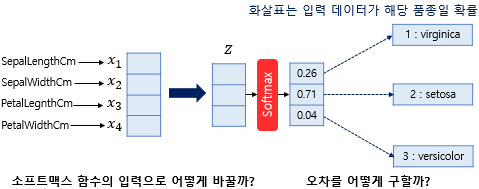

여기서는 batch size = 1이라고 생각하자.

하나의 sample data는 4개의 독립 변수 $x$를 가지는데 이는 모델이 4-dim vector를 input으로 받음을 의미한다. 그러나 softmax function의 input으로 사용되는 vector의 dimension은 분류하고자 하는 class 개수가 되어야 하므로 3-dim vector로 변환되어야 한다.

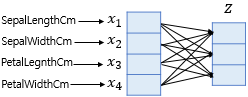

sample data vector를 softmax function의 input vector로 차원을 축소하는 방법은, softmax function의 input vector $z$의 차원 수만큼 결과값이 나오도록 가중치 곱을 진행하는 것이다.

error 계산의 경우 실제값을 one-hot-vector를 이용하여 계산한다.

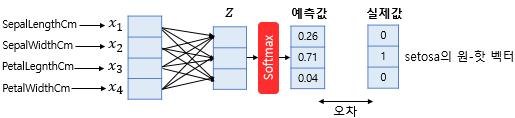

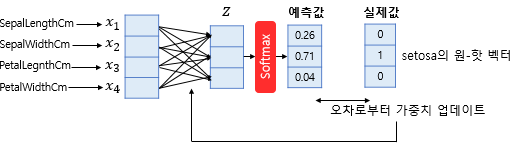

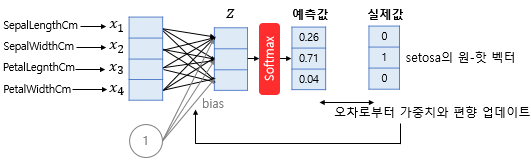

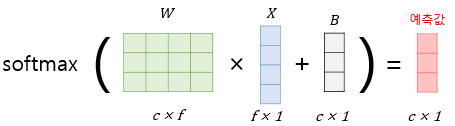

Softmax Regression을 vector와 matrix 연산으로 이해해보자. 입력을 feature의 수만큼의 dimension을 가진 input vector $x$라고 하고, weight matrix을 $W$, bias를 $b$라 할 때 위와 같은 그림으로 표현된다. 여기서 $f$는 feature의 수이며, $c$는 class의 개수이다.

## 3. 붓꽃 품종 분류 행렬 연산으로 이해하기

위 예제의 data는 sample이 5개, feature가 4개이므로 5 x 4 matrix $X$로 정의됨.

$$X = \begin{pmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34} \\
x_{41} & x_{42} & x_{43} & x_{44} \\
x_{51} & x_{52} & x_{53} & x_{54}
\end{pmatrix}$$

선택지가 총 3개인 문제이므로 hypothesis의 예측값으로 얻는 matrix $\hat{Y}$의 column의 개수는 3. 즉 size는 5 x 3이다.

$$\hat{Y} = \begin{pmatrix}
y_{11} & y_{12} & y_{13} \\
y_{21} & y_{22} & y_{23} \\
y_{31} & y_{32} & y_{33} \\
y_{41} & y_{42} & y_{43} \\
y_{51} & y_{52} & y_{53}
\end{pmatrix}$$

이를 통해 $W$의 크기가 4 x 3이라는 점을 유추할 수 있음. Bias matrix $B$는 $\hat{Y}$와 size 동일하므로 5 x 3.

결과적으로 hypothesis는 다음과 같음.

$$\hat{Y} = \text{softmax}(XW + B)$$

$$\begin{pmatrix}
y_{11} & y_{12} & y_{13} \\
y_{21} & y_{22} & y_{23} \\
y_{31} & y_{32} & y_{33} \\
y_{41} & y_{42} & y_{43} \\
y_{51} & y_{52} & y_{53}
\end{pmatrix}
= \text{softmax} \left(
\begin{pmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34} \\
x_{41} & x_{42} & x_{43} & x_{44} \\
x_{51} & x_{52} & x_{53} & x_{54}
\end{pmatrix}
\begin{pmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23} \\
w_{31} & w_{32} & w_{33} \\
w_{41} & w_{42} & w_{43}
\end{pmatrix}
+
\begin{pmatrix}
b_1 & b_2 & b_3 \\
b_1 & b_2 & b_3 \\
b_1 & b_2 & b_3 \\
b_1 & b_2 & b_3 \\
b_1 & b_2 & b_3
\end{pmatrix}
\right)$$

## 4. Cost Function

### 1) Cross Entropy Function

아래에서 $y$는 실제 값, $k$는 class의 개수로 정의함. $y_j$는 실제값 one-hot vector의 $j$번째 index를 의미하며, $p_j$는 sample data가 $j$번째 class일 확률을 나타냄. 표기에 따라 $\hat{y_j}$로 표현하기도 함.

$$ \text{cost}(W) = - \sum_{j=1}^{k} y_j \log(p_j) $$

이를 $n$개의 whole data에 대한 mean을 구하면 최종 cost function은 아래와 같음.

$$\text{cost}(W) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{k} y_j^{(i)} \log(p_j^{(i)})$$

# 5-3. Softmax Regression 다양한 방법으로 구현하기

## 1. Softmax Regression의 cost function 구현

In [3]:
import torch
import torch.nn.functional as F

In [4]:
torch.manual_seed(1)

### 1) PyTorch로 softmax의 cost function 구현하기 (low-level)

In [5]:
z = torch.FloatTensor([1, 2, 3])

In [6]:
hypothesis = F.softmax(z, dim = 0)
print(hypothesis)

tensor([0.0900, 0.2447, 0.6652])


In [7]:
hypothesis.sum()

tensor(1.)

In [8]:
z = torch.rand(3, 5, requires_grad = True)

In [9]:
hypothesis = F.softmax(z, dim = 1)
print(hypothesis)

tensor([[0.2645, 0.1639, 0.1855, 0.2585, 0.1277],
        [0.2430, 0.1624, 0.2322, 0.1930, 0.1694],
        [0.2226, 0.1986, 0.2326, 0.1594, 0.1868]], grad_fn=<SoftmaxBackward0>)


In [10]:
y = torch.randint(5, (3,)).long() # 각 sample에 대하여 임의의 레이블 생성
print(y)

tensor([0, 2, 1])


In [11]:
# 각 레이블에 대하여 one-hot encoding 수행
# 모든 원소가 0의 값을 가진 3 x 5 tensor 생성
y_one_hot = torch.zeros_like(hypothesis)
y_one_hot.scatter_(1, y.unsqueeze(1), 1) # dim = 1, y.unsqueeze(1)이 알려주는 위치에 숫자 1 삽입

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])

In [12]:
print(y_one_hot)

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])


In [13]:
cost = (y_one_hot * -torch.log(hypothesis)).sum(dim = 1).mean()
print(cost)

tensor(1.4689, grad_fn=<MeanBackward0>)


### 2) PyTorch로 Softmax의 cost function 구현하기 (high-level)

#### 2-1) F.softmax() + torch.log() = F.log_softmax()

In [14]:
# Low level
torch.log(F.softmax(z, dim = 1))

tensor([[-1.3301, -1.8084, -1.6846, -1.3530, -2.0584],
        [-1.4147, -1.8174, -1.4602, -1.6450, -1.7758],
        [-1.5025, -1.6165, -1.4586, -1.8360, -1.6776]], grad_fn=<LogBackward0>)

In [15]:
# High level
F.log_softmax(z, dim = 1)

tensor([[-1.3301, -1.8084, -1.6846, -1.3530, -2.0584],
        [-1.4147, -1.8174, -1.4602, -1.6450, -1.7758],
        [-1.5025, -1.6165, -1.4586, -1.8360, -1.6776]],
       grad_fn=<LogSoftmaxBackward0>)

####2-2) F.log_softmax() + F.nll_loss() = F.cross_entropy

In [16]:
# Low level
(y_one_hot * -torch.log(F.softmax(z, dim = 1))).sum(dim = 1).mean()

tensor(1.4689, grad_fn=<MeanBackward0>)

In [17]:
(y_one_hot * - F.log_softmax(z, dim=1)).sum(dim=1).mean()

tensor(1.4689, grad_fn=<MeanBackward0>)

In [18]:
# High level
F.nll_loss(F.log_softmax(z, dim=1), y) # Negative Log Likelihood의 약자

tensor(1.4689, grad_fn=<NllLossBackward0>)

In [19]:
F.cross_entropy(z, y) # 이 경우, cost function에 softmax function까지 포함하고 있음을 기억할 것.

tensor(1.4689, grad_fn=<NllLossBackward0>)

####2-3) nn.CrossEntropyLoss(): Class를 이용한 구현 방식

In [20]:
import torch.nn as nn

In [21]:
nn.CrossEntropyLoss()(z, y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

F.cross_entropy()는 function이나, nn.CrossEntropyLoss는 class이다.

In [22]:
# Step 1. 클래스로 객체 생성
criterion = nn.CrossEntropyLoss()

# Step 2. 생성된 객체 사용
loss = criterion(z, y)
print(loss)

tensor(1.4689, grad_fn=<NllLossBackward0>)


In [23]:
# loss function 객체를 한 번만 생성.
criterion = nn.CrossEntropyLoss()

# 같은 객체로 여러 번 계산 가능
loss1 = criterion(z, y)
loss2 = criterion(z, y)

z2 = torch.rand(3, 5, requires_grad = True)
y2 = torch.randint(5, (3,)).long()
loss3 = criterion(z2, y2)

In [24]:
# 평균 대신 합계를 구하는 설정
# 손실함수 객체를 한 번만 생성. 이제 호출할때는 무조건 criterion으로만 호출함.
criterion = nn.CrossEntropyLoss(reduction='sum')

# 같은 객체로 여러 번 계산 가능
loss1 = criterion(z, y)           # 첫 번째 계산
loss2 = criterion(z, y)           # 두 번째 계산

# 새로운 데이터가 있다면
z2 = torch.rand(3, 5, requires_grad=True)
y2 = torch.randint(5, (3,)).long()
loss3 = criterion(z2, y2)         # 새 데이터로 계산

## 2. Softmax Regression 구현하기

### 1) Dataset 준비

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [26]:
torch.manual_seed(1)

In [27]:
x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]] # 총 8개의 sample
y_train = [2, 2, 2, 1, 1, 1, 0, 0] # 레이블: 0, 1, 2. 즉 3개의 class
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

### 2) Softmax regression 구현하기 (low-level)

In [28]:
print(x_train.shape)
print(y_train.shape)

torch.Size([8, 4])
torch.Size([8])


최종적으로 사용할 레이블은 y_train에서 one-hot encoding을 한 결과여야 함. 즉, 8 x 3의 size.

In [29]:
y_one_hot = torch.zeros(8, 3)
y_one_hot.scatter_(1, y_train.unsqueeze(1), 1)
print(y_one_hot.shape)

torch.Size([8, 3])


즉 W 행렬의 크기는 4 x 3임을 알 수 있음.

In [30]:
# model 초기화
W = torch.zeros((4, 3), requires_grad = True)
b = torch.zeros((1, 3), requires_grad = True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr = 0.1)

In [31]:
nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # 가설
    hypothesis = F.softmax(x_train.matmul(W) + b, dim=1)

    # 비용 함수
    cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.622999
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467661
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285072
Epoch 1000/1000 Cost: 0.248155


### 3) Softmax Regression 구현하기 (high-level)

In [32]:
# model 초기화
W = torch.zeros((4, 3), requires_grad = True)
b = torch.zeros((1, 3), requires_grad = True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr = 0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

  # Cost 계산
  z = x_train.matmul(W) + b
  cost = F.cross_entropy(z, y_train)

  # cost로 H(x) 개선
  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.623000
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467662
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285073
Epoch 1000/1000 Cost: 0.248155


### 4) Softmax Regression nn.Module로 구현하기

In [33]:
# 모델을 선언 및 초기화. 4개의 feature를 가지고 3개의 class로 분류. input_dim = 4, output_dim = 3
model = nn.Linear(4, 3)

In [35]:
# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr = 0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.cross_entropy(prediction, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 20번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.616785
Epoch  100/1000 Cost: 0.658891
Epoch  200/1000 Cost: 0.573443
Epoch  300/1000 Cost: 0.518151
Epoch  400/1000 Cost: 0.473265
Epoch  500/1000 Cost: 0.433516
Epoch  600/1000 Cost: 0.396563
Epoch  700/1000 Cost: 0.360914
Epoch  800/1000 Cost: 0.325392
Epoch  900/1000 Cost: 0.289178
Epoch 1000/1000 Cost: 0.254148


### 5) Softmax Regression Class로 구현하기

In [37]:
class SoftmaxClassifierModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(4, 3) # Output이 3.

  def forward(self, x):
    return self.linear(x)

In [38]:
model = SoftmaxClassifierModel()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr = 0.1)

In [39]:
nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.cross_entropy(prediction, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 20번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 2.637636
Epoch  100/1000 Cost: 0.647903
Epoch  200/1000 Cost: 0.564643
Epoch  300/1000 Cost: 0.511043
Epoch  400/1000 Cost: 0.467249
Epoch  500/1000 Cost: 0.428280
Epoch  600/1000 Cost: 0.391924
Epoch  700/1000 Cost: 0.356742
Epoch  800/1000 Cost: 0.321577
Epoch  900/1000 Cost: 0.285617
Epoch 1000/1000 Cost: 0.250818


# 5-4. Softmax Regression으로 MNIST data 분류하기

MNIST data: http://yann.lecun.com/exdb/mnist

## 1. MNIST data 이해하기

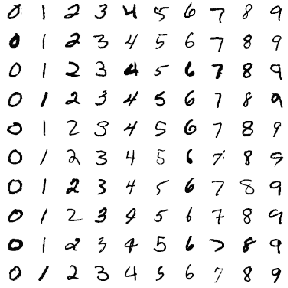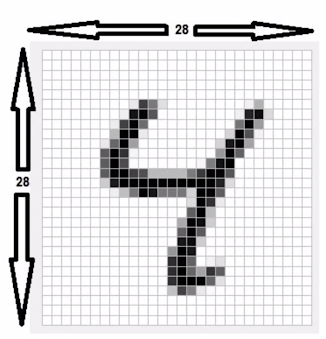
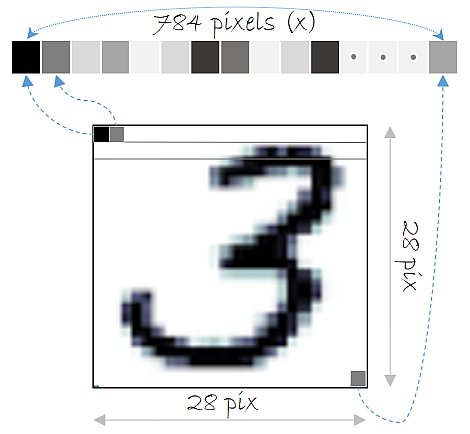

In [ ]:
for X, Y in data_loader:
  # input image를 [batch_size x 784]의 크기로 reshape
  # 레이블은 one-hot encoding
  X = X.view(-1, 28 * 28)

## 2. torchvision

torchvision: https://pytorch.org/docs/stable/torchvision/index.html

이미 유명한 datasets, 이미 구현되어 있는 famous models, 일반적인 이미지 전처리 도구들을 포함하고 있는 package

## 3. 분류기 구현을 위한 사전 설정

In [13]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import random

In [14]:
USE_CUDA = torch.cuda.is_available() # GPU를 사용 가능하면 True, 아니면 False
device = torch.device("cuda" if USE_CUDA else "cpu")
print("다음 기기로 학습합니다:", device)

다음 기기로 학습합니다: cuda


In [15]:
# for reproducibility
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
  torch.cuda.manual_seed_all(777)

In [16]:
# hyperparameters
training_epochs = 15
batch_size = 100

## 4. MNIST 분류기 구현하기

In [17]:
# MNIST dataset
mnist_train = dsets.MNIST(root = 'MNIST_data/',
                          train = True,
                          transform = transforms.ToTensor(),
                          download = True)

mnist_test = dsets.MNIST(root = 'MNIST_data/',
                         train = False,
                         transform = transforms.ToTensor(),
                         download = True)

In [18]:
# dataset loader
data_loader = DataLoader(dataset = mnist_train,
                         batch_size = batch_size,
                         shuffle = True,
                         drop_last = True)

In [19]:
# MNIST data image of shape 28 * 28 = 784
linear = nn.Linear(784, 10, bias = True).to(device)

In [20]:
# cost function and optimizer define
criterion = nn.CrossEntropyLoss().to(device) # 내부적으로 softmax function 포함
optimizer = torch.optim.SGD(linear.parameters(), lr = 0.1)

In [21]:
for epoch in range(training_epochs): # 앞서 training_epochs의 값은 15로 지정함.
    avg_cost = 0
    total_batch = len(data_loader)

    for X, Y in data_loader:
        # 배치 크기가 100이므로 아래의 연산에서 X는 (100, 784)의 텐서가 된다.
        X = X.view(-1, 28 * 28).to(device)
        # 레이블은 원-핫 인코딩이 된 상태가 아니라 0 ~ 9의 정수.
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = linear(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.9f}'.format(avg_cost))

print('Learning finished')

Epoch: 0001 cost = 0.535150588
Epoch: 0002 cost = 0.359577715
Epoch: 0003 cost = 0.331264257
Epoch: 0004 cost = 0.316404700
Epoch: 0005 cost = 0.307107002
Epoch: 0006 cost = 0.300456554
Epoch: 0007 cost = 0.294933408
Epoch: 0008 cost = 0.290956199
Epoch: 0009 cost = 0.287074089
Epoch: 0010 cost = 0.284515619
Epoch: 0011 cost = 0.281914055
Epoch: 0012 cost = 0.279526889
Epoch: 0013 cost = 0.277636588
Epoch: 0014 cost = 0.275874794
Epoch: 0015 cost = 0.274422795
Learning finished


Accuracy: 0.8883000016212463
Label:  8
Prediction:  3


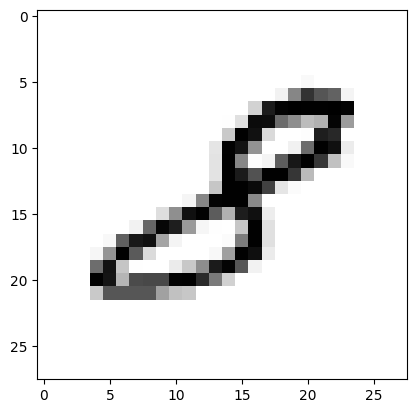

In [23]:
# test data를 사용하여 model testing
with torch.no_grad(): # torch.no_grad()를 하면 gradient 계산을 수행하지 않음.
  X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
  Y_test = mnist_test.test_labels.to(device)

  prediction = linear(X_test)
  correct_prediction = torch.argmax(prediction, 1) == Y_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

  # MNIST text data에서 무작위로 하나를 뽑아서 prediction
  r = random.randint(0, len(mnist_test) - 1)
  X_single_data = mnist_test.test_data[r : r + 1].view(-1, 28 * 28).float().to(device)
  Y_single_data = mnist_test.test_labels[r : r + 1].to(device)

  print('Label: ', Y_single_data.item())
  single_prediction = linear(X_single_data)
  print('Prediction: ', torch.argmax(single_prediction, 1).item())

  plt.imshow(mnist_test.test_data[r:r + 1].view(28, 28), cmap='Greys', interpolation='nearest')
  plt.show()